# Lab 3: Data Preprocessing & Feature Engineering

> Preparing Real-World Data for Machine Learning Models in Python


**Course:** CS4082 – Machine Learning  
**Instructor:** Dr. Naila Marir  
**Student Name:** Sarah Alsebae  
**Student ID:** S23108327  
**Semester:** Spring 2026

#Part 1: Understanding the Problem with Messy Data

##2.1 Create a Messy Dataset

In [390]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(
        ['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nMissing values per column:')
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows:
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


##2.2 Identify the Issues

In [391]:
print ('=== Data Types === ')
print ( df . dtypes )

print ('\n=== Missing Values === ')
print ( df . isnull () .sum () )

print ('\n=== Numeric Ranges ( notice the scale differences !) === ')
print ( df . describe () . round (2) )

print ('\n=== Categorical Columns === ')
for col in ['gender', 'city', 'smoker']:
    print ( f'{col }: {df[col ]. unique ()}')

=== Data Types === 
age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

=== Missing Values === 
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== Numeric Ranges ( notice the scale differences !) === 
          age  blood_pressure  cholesterol     bmi  heart_disease
count  190.00          195.00       195.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.71           26.48        60.97    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.00          112.20       205.75   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     65.00          159.75  

#Task 1: Explore the Messy Data

In [392]:
# Use df.info() to see column types and non-null counts in one view.
df.info()

#Calculate the percentage of missing values for each column (hint: divide by len(df) and multiply by 100).
missing_percentage = (df.isnull().sum() / len(df)) * 100
print('\nPercentage of missing values per column:')
print(missing_percentage)

#Use df[’city’].value counts() to see how many patients come from each city.
print('\nPatient count per city:')
print(df['city'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             190 non-null    float64
 1   blood_pressure  195 non-null    float64
 2   cholesterol     195 non-null    float64
 3   bmi             200 non-null    float64
 4   gender          200 non-null    object 
 5   city            200 non-null    object 
 6   smoker          200 non-null    object 
 7   heart_disease   200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB

Percentage of missing values per column:
age               5.0
blood_pressure    2.5
cholesterol       2.5
bmi               0.0
gender            0.0
city              0.0
smoker            0.0
heart_disease     0.0
dtype: float64

Patient count per city:
city
Dammam    59
Jeddah    52
Riyadh    47
Makkah    42
Name: count, dtype: int64


**- Which column has the most missing values?**

The 'age' column has the most missing values, with 5.0% of its entries being absent.

#Part 2: Handling Missing Values


##2.1 Impute Numeric Columns

In [393]:
from sklearn . impute import SimpleImputer

# Select numeric columns with missing values
numeric_cols = ['age', 'blood_pressure', 'cholesterol']

# Create an imputer that fills NaN with the median
imputer = SimpleImputer ( strategy ='median' )

# Fit on the data and transform
df [ numeric_cols ] = imputer . fit_transform ( df [ numeric_cols ])

# Verify : no more missing values !
print ('Missing values after imputation :')
print ( df [ numeric_cols ]. isnull () .sum () )

Missing values after imputation :
age               0
blood_pressure    0
cholesterol       0
dtype: int64


##2.2 Verify the Fix

In [394]:
print(f'Total missing values in entire dataset: {df.isnull().sum().sum()}')
print(f'\nDataset shape (no rows lost !): {df.shape}')
print(df.describe().round(2))

Total missing values in entire dataset: 0

Dataset shape (no rows lost !): (200, 8)
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.34          136.08       252.36   29.33           0.44
std     18.23           26.15        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


#Task 2: Experiment with Imputation


In [395]:
df_original = df.copy() #so we can do the comparison of mean and median strategies.

#Re-create the messy dataset (run the creation code again).
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(
        ['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nMissing values per column:')
print(df.isnull().sum())

#This time, use strategy=’mean’ instead of ’median’. Compare the filled values – are they different? By how much?
from sklearn . impute import SimpleImputer

# Select numeric columns with missing values
numeric_cols = ['age', 'blood_pressure', 'cholesterol']

# Create an imputer that fills NaN with the mean
mean_imputer = SimpleImputer(strategy='mean')
df_mean = df_original.copy()

# Fit on the data and transform
df_mean[numeric_cols] = mean_imputer.fit_transform(df_original[numeric_cols])

# Verify : no more missing values !
print ('Missing values after imputation :')
print ( df_mean[ numeric_cols ]. isnull () .sum () )

# Median version
median_imputer = SimpleImputer(strategy='median')
df_median = df_original.copy()
df_median[numeric_cols] = median_imputer.fit_transform(df_original[numeric_cols])

#Compare the filled values – are they different? By how much?
difference = df_mean[numeric_cols] - df_median[numeric_cols]
print("Average difference per column:")
print(difference.mean())
print("\nMaximum difference per column:")
print(difference.max())


#Try using df.dropna() instead. How many rows do you lose? Is that acceptable for 200 samples?
data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(
        ['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nMissing values per column:')
print(df.isnull().sum())

df = df.dropna()
print(f'Dataset shape: {df.shape}')

Dataset shape: (200, 8)

First 5 rows:
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64
Missing values after imputation :
age               0
blood_pressure    0
cholesterol       0
dtype: int64
Average difference per column:
age               0.0
blood_pressure    0.0
cholesterol       0.0
dtype: float64

Max

**1. This time, use strategy=’mean’ instead of ’median’. Compare the filled values – are they different? By how much?**

> No, they are not different. The average and maximum differences are 0.0, so mean and median produced the same filled values in this case.

**2. Try using df.dropna() instead. How many rows do you lose? Is that acceptable for 200 samples?**

> We lose 20 rows (200 → 180). That is 10%, which is generally acceptable for 200 samples.

**3. Think: In what scenario would dropping rows be better than imputing?**

> Dropping rows is better when the missing data is very small and random, and when you do not want to introduce estimated (fake) values into your data.

#Part 3: Encoding Categorical Variables

##3.1  Label Encoding for Binary Variables


In [396]:
from sklearn.preprocessing import LabelEncoder

# Encode gender : Female =0 , Male =1
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

# Encode smoker : No =0 , Yes =1
le_smoker = LabelEncoder()
df['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])

print('Original vs Encoded :')
print(df[['gender', 'gender_encoded',
'smoker', 'smoker_encoded']].head(8))

Original vs Encoded :
   gender  gender_encoded smoker  smoker_encoded
0  Female               0     No               0
2  Female               0     No               0
3    Male               1    Yes               1
4  Female               0    Yes               1
5  Female               0    Yes               1
6  Female               0    Yes               1
7  Female               0     No               0
8  Female               0     No               0


##3.2 One-Hot Encoding for Multi-Category Variables

In [397]:
# One -Hot Encode the city column
city_dummies = pd.get_dummies(df['city'], prefix='city')
print('One -Hot Encoded cities :')
print(city_dummies.head())

# Add to dataframe and drop original text columns
df = pd.concat([df, city_dummies], axis=1)
df = df.drop(columns=['gender', 'city', 'smoker'])

print(f'\nNew shape : {df.shape}')
print(f'New columns : {list(df.columns)}')

One -Hot Encoded cities :
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False         True        False        False
2        False        False         True        False
3        False         True        False        False
4        False         True        False        False
5        False         True        False        False

New shape : (180, 11)
New columns : ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


#Task 3: Practice Encoding

In [398]:
#Print the first 10 rows of the fully encoded dataset. How many columns do you have now?
print("First 10 rows of the fully encoded dataset:")
print(df.head(10))
print(f"\nNumber of columns now: {df.shape[1]}")

#Bonus: Use pd.get_dummies(df['city'], prefix='city', drop_first=True).
print("\nBonus: One-Hot Encoding with drop_first=True")
city_dummies_dropped = pd.get_dummies(df_original['city'], prefix='city', drop_first=True)
print(city_dummies_dropped.head())

First 10 rows of the fully encoded dataset:
     age  blood_pressure  cholesterol   bmi  heart_disease  gender_encoded  \
0   51.0           123.6        266.4  20.9              1               0   
2   72.0           100.1        187.9  23.7              0               0   
3   72.0            90.2        273.8  26.9              0               1   
4   43.0           147.4        214.7  19.5              1               0   
5   60.0           136.4        316.9  37.2              0               0   
6   27.0           143.4        275.9  36.4              1               0   
7   47.0           161.4        189.8  35.6              0               0   
8   67.0           148.2        162.9  25.2              0               0   
9   35.0           105.7        158.5  22.2              1               1   
10  34.0           122.5        224.3  33.3              1               0   

    smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0                0      

**1. Print the first 10 rows of the fully encoded dataset. How many columns do you have now?**

> The fully encoded dataset has 11 columns.

**2. What would happen if a city column had 50 unique values? How many new columns would One-Hot encoding create? Is this a problem?**

> If there were 50 unique cities, One-Hot Encoding would create 50 new columns.
 This can be a problem because it makes the dataset much larger and can make machine learning models harder to train or less accurate.

**3. Bonus: Use pd.get dummies(df[’city’], prefix=’city’, drop first=True). What changes and why might this be useful?**

> With drop_first=True, one city column is removed (in this case: city_Dammam).
This is useful because it avoids duplicate information between columns.
Basically it removes one unnecessary column and makes the model more stable.

#Part 4: Feature Scaling


##4.1 Apply StandardScaler

In [399]:
from sklearn.preprocessing import StandardScaler

# Prepare features and target
feature_cols = ['age', 'blood_pressure', 'cholesterol', 'bmi',
'gender_encoded', 'smoker_encoded',
'city_Dammam', 'city_Jeddah',
'city_Makkah', 'city_Riyadh']

X = df[feature_cols].values.astype(float) #Use .astype(float) here to ensure the array is purely numeric
y = df['heart_disease'].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compare before and after
import pandas as pd
comparison = pd.DataFrame({
'Feature': feature_cols,
'Original Mean': X.mean(axis=0).round(2),
'Original Std': X.std(axis=0).round(2),
'Scaled Mean': X_scaled.mean(axis=0).round(2),
'Scaled Std': X_scaled.std(axis=0).round(2)
})
print(comparison.to_string(index=False))

       Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
           age          46.28         17.50          0.0         1.0
blood_pressure         132.72         24.36          0.0         1.0
   cholesterol         245.62         58.88         -0.0         1.0
           bmi          30.20          7.10          0.0         1.0
gender_encoded           0.51          0.50          0.0         1.0
smoker_encoded           0.29          0.45          0.0         1.0
   city_Dammam           0.22          0.42          0.0         1.0
   city_Jeddah           0.32          0.47         -0.0         1.0
   city_Makkah           0.25          0.43         -0.0         1.0
   city_Riyadh           0.21          0.40          0.0         1.0


##4.2  Visualize the Effect of Scaling


/tmp/ipython-input-1096/1430373653.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes [0]. boxplot ([ X [: , 0] , X [: , 1] , X [: , 2] , X [: , 3]] ,
/tmp/ipython-input-1096/1430373653.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes [1]. boxplot ([ X_scaled [: , 0] , X_scaled [: , 1] ,


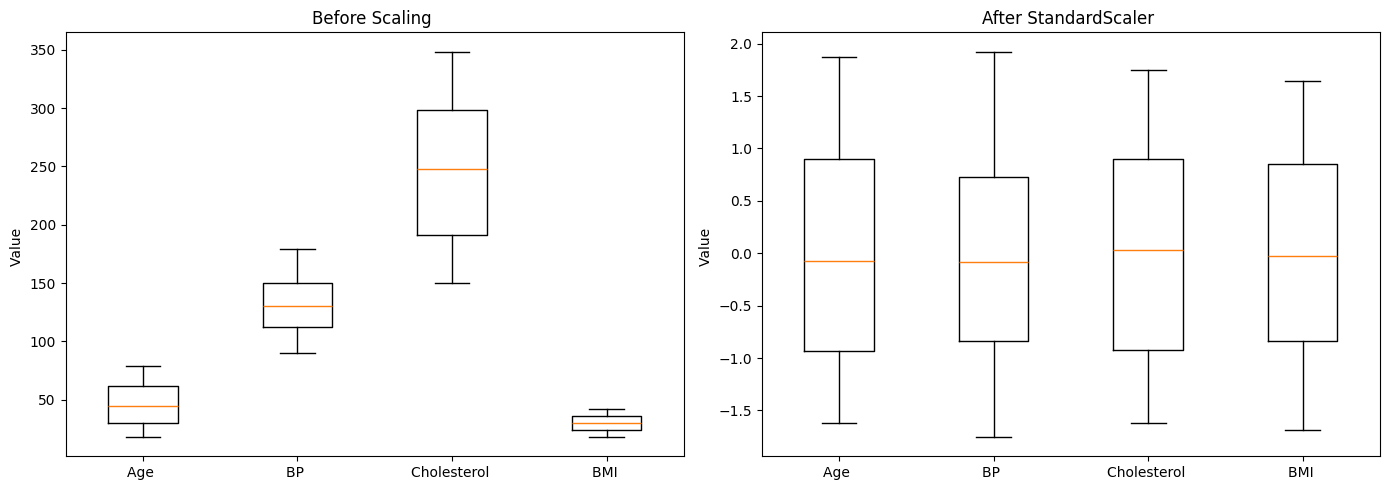

In [400]:
import matplotlib . pyplot as plt

fig , axes = plt . subplots (1 , 2 , figsize =(14 , 5) )

# Before scaling
axes [0]. boxplot ([ X [: , 0] , X [: , 1] , X [: , 2] , X [: , 3]] ,
labels =[ 'Age ', 'BP ', 'Cholesterol ', 'BMI '])
axes [0]. set_title ('Before Scaling ')
axes [0]. set_ylabel ('Value ')

# After scaling
axes [1]. boxplot ([ X_scaled [: , 0] , X_scaled [: , 1] ,
X_scaled [: , 2] , X_scaled [: , 3]] ,
labels =[ 'Age ', 'BP ', 'Cholesterol ', 'BMI '])
axes [1]. set_title ('After StandardScaler ')
axes [1]. set_ylabel ('Value ')

plt . tight_layout ()
plt . show ()

#Task 4: Compare Scalers

/tmp/ipython-input-1096/2986347015.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
/tmp/ipython-input-1096/2986347015.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_minmax_scaled[:, 0], X_minmax_scaled[:, 1],


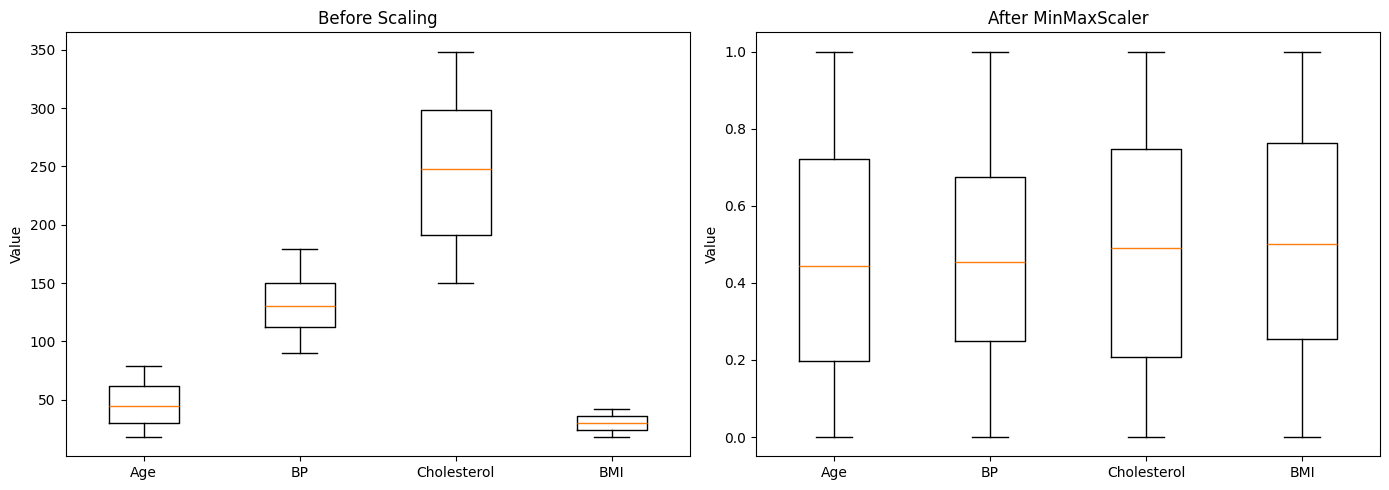

In [401]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

#Apply MinMaxScaler to the same data.
scaler_minmax = MinMaxScaler()
X_minmax_scaled = scaler_minmax.fit_transform(X)

#Create the same box plot comparison for MinMaxScaler.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling (original data)
axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

# After MinMaxScaler
axes[1].boxplot([X_minmax_scaled[:, 0], X_minmax_scaled[:, 1],
                 X_minmax_scaled[:, 2], X_minmax_scaled[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title('After MinMaxScaler')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

**1. Apply MinMaxScaler to the same data. What range do the values fall into?**

> When MinMaxScaler is applied, the values fall into a range between 0 and 1.

**2. Create the same box plot comparison for MinMaxScaler. How does it differ from StandardScaler?**

> MinMaxScaler scales all values to be within a specific range (like 0 to 1), making the box plots show data within that fixed boundary. StandardScaler centers the data around zero, with most values between -2 and 2, but it doesn't enforce a strict maximum or minimum boundary.

**3. Think: If your data has many outliers, which scaler would be more robust? Why?**

> If your data has many outliers, StandardScaler would generally be more robust than MinMaxScaler. This is because MinMaxScaler uses the minimum and maximum values, which are heavily influenced by outliers. StandardScaler uses the mean and standard deviation, which are less affected by extreme outliers.

#Part 5: The Scaling Impact – KNN Before and After

##5.1 Experiment: KNN Without Scaling vs. With Scaling

In [402]:
from sklearn . model_selection import train_test_split
from sklearn . neighbors import KNeighborsClassifier
from sklearn . metrics import accuracy_score

# Split data
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )

X_train_s , X_test_s , _ , _ = train_test_split (
X_scaled , y , test_size =0.2 , random_state =42 , stratify = y )

# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier ( n_neighbors =5)
knn_raw . fit ( X_train , y_train )
raw_acc = accuracy_score ( y_test , knn_raw . predict ( X_test ) )

# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier ( n_neighbors =5)
knn_scaled . fit ( X_train_s , y_train )
scaled_acc = accuracy_score ( y_test , knn_scaled . predict ( X_test_s ) )

print ( f'KNN Accuracy WITHOUT scaling : { raw_acc :.2%} ')
print ( f'KNN Accuracy WITH scaling : { scaled_acc :.2%} ')
print ( f'Improvement : {( scaled_acc - raw_acc ) :.2%} ')

KNN Accuracy WITHOUT scaling : 33.33% 
KNN Accuracy WITH scaling : 61.11% 
Improvement : 27.78% 


##5.2 Bonus: Decision Tree Comparison

In [403]:
from sklearn . tree import DecisionTreeClassifier

# Decision Tree WITHOUT scaling
dt_raw = DecisionTreeClassifier ( random_state =42)
dt_raw . fit ( X_train , y_train )
dt_raw_acc = accuracy_score ( y_test , dt_raw . predict ( X_test ) )

# Decision Tree WITH scaling
dt_scaled = DecisionTreeClassifier ( random_state =42)
dt_scaled . fit ( X_train_s , y_train )
dt_scaled_acc = accuracy_score ( y_test , dt_scaled . predict ( X_test_s ) )

print ( f'DT Accuracy WITHOUT scaling : { dt_raw_acc :.2%} ')
print ( f'DT Accuracy WITH scaling : { dt_scaled_acc :.2%} ')

DT Accuracy WITHOUT scaling : 50.00% 
DT Accuracy WITH scaling : 44.44% 


#Task 5: Investigate Scaling Effects

**1. Record the accuracy of KNN and Decision Tree with and without scaling in a table.**


```
| Model          | Without Scaling | With Scaling |
|----------------|-----------------|--------------|
| KNN            |     33.33%      |    61.11%    |
| Decision Tree  |     50.00%      |    44.44%    |
```




In [404]:
#Try KNN with n neighbors=3 and n neighbors=10, both with and without scaling.

# Split data
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )

X_train_s , X_test_s , _ , _ = train_test_split (
X_scaled , y , test_size =0.2 , random_state =42 , stratify = y )

#KNN with n neighbors=3:

# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier ( n_neighbors =3)
knn_raw . fit ( X_train , y_train )
raw_acc = accuracy_score ( y_test , knn_raw . predict ( X_test ) )

# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier ( n_neighbors =3)
knn_scaled . fit ( X_train_s , y_train )
scaled_acc = accuracy_score ( y_test , knn_scaled . predict ( X_test_s ) )

print("KNN with n neighbors=3:")
print ( f'\nKNN Accuracy WITHOUT scaling : { raw_acc :.2%} ')
print ( f'KNN Accuracy WITH scaling : { scaled_acc :.2%} ')
print ( f'Improvement : {( scaled_acc - raw_acc ) :.2%} ')

#KNN with n neighbors=10

# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier ( n_neighbors =10)
knn_raw . fit ( X_train , y_train )
raw_acc = accuracy_score ( y_test , knn_raw . predict ( X_test ) )

# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier ( n_neighbors =10)
knn_scaled . fit ( X_train_s , y_train )
scaled_acc = accuracy_score ( y_test , knn_scaled . predict ( X_test_s ) )

print("\nKNN with n neighbors=10:")
print ( f'\nKNN Accuracy WITHOUT scaling : { raw_acc :.2%} ')
print ( f'KNN Accuracy WITH scaling : { scaled_acc :.2%} ')
print ( f'Improvement : {( scaled_acc - raw_acc ) :.2%} ')

KNN with n neighbors=3:

KNN Accuracy WITHOUT scaling : 30.56% 
KNN Accuracy WITH scaling : 50.00% 
Improvement : 19.44% 

KNN with n neighbors=10:

KNN Accuracy WITHOUT scaling : 36.11% 
KNN Accuracy WITH scaling : 50.00% 
Improvement : 13.89% 


**2. Try KNN with n neighbors=3 and n neighbors=10, both with and without scaling. Does scaling always help?**

> In our experiments with n_neighbors=3 and n_neighbors=10, scaling significantly improved KNN's accuracy in both cases. So, in these specific scenarios, scaling definitely helped.

**3. Write 2–3 sentences explaining why KNN benefits from scaling but Decision Trees do not.**

> KNN works by measuring distances between data points, so features with larger values can unfairly dominate the distance calculations if not scaled. Decision Trees, on the other hand, make decisions based on thresholds, which are not affected by the overall scale of the features.

#Part 6: Building a Preprocessing Pipeline

##6.1  Create a Pipeline

In [405]:
from sklearn . pipeline import Pipeline
from sklearn . preprocessing import StandardScaler
from sklearn . neighbors import KNeighborsClassifier

# Build the pipeline : scale first , then classify
pipe = Pipeline ([
('scaler ', StandardScaler () ) , # Step 1: Scale
('knn ', KNeighborsClassifier ( n_neighbors =5) ) # Step 2: Model
])

# Split the original ( unscaled ) data
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )

# The pipeline handles scaling internally !
pipe . fit ( X_train , y_train )
pipe_acc = accuracy_score ( y_test , pipe . predict ( X_test ) )

print ( f'Pipeline KNN Accuracy : { pipe_acc :.2%} ')

Pipeline KNN Accuracy : 61.11% 


##6.2 Swap Models Easily

In [406]:
from sklearn . tree import DecisionTreeClassifier
from sklearn . svm import SVC

# Pipeline with SVM
pipe_svm = Pipeline ([
('scaler ', StandardScaler () ) ,
('svm ', SVC ( kernel ='rbf', random_state =42) )
])
pipe_svm . fit ( X_train , y_train )
svm_acc = accuracy_score ( y_test , pipe_svm . predict ( X_test ) )

# Pipeline with Decision Tree
pipe_dt = Pipeline ([
('scaler ', StandardScaler () ) ,
('dt ', DecisionTreeClassifier ( random_state =42) )
])
pipe_dt . fit ( X_train , y_train )
dt_acc = accuracy_score ( y_test , pipe_dt . predict ( X_test ) )

print ( f'Pipeline KNN Accuracy : { pipe_acc :.2%} ')
print ( f'Pipeline SVM Accuracy : { svm_acc :.2%} ')
print ( f'Pipeline DT Accuracy : { dt_acc :.2%} ')

Pipeline KNN Accuracy : 61.11% 
Pipeline SVM Accuracy : 55.56% 
Pipeline DT Accuracy : 50.00% 


#Task 6: Build Your Own Pipeline


In [407]:
#Create a pipeline that uses MinMaxScaler instead of StandardScaler with KNN. Compare the accuracy.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Pipeline with MinMaxScaler and KNN
pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),          # Step 1: scale with MinMax
    ('knn', KNeighborsClassifier(n_neighbors=5))  # Step 2: KNN
])

pipe_minmax.fit(X_train, y_train)
minmax_acc = accuracy_score(y_test, pipe_minmax.predict(X_test))
print(f'Pipeline KNN with MinMaxScaler Accuracy: {minmax_acc:.2%}')
print("\nCompare the accuracy:")
print("The KNN pipeline with StandardScaler got 61.11% accuracy, while the pipeline with MinMaxScaler got 50.00%. \nThis shows that scaling method affects KNN, and in this case, StandardScaler works better than MinMaxScaler.")

#Add SimpleImputer as the first step in your pipeline (before the scaler). Now the pipeline handles missing values AND scaling automatically.
#Hint: The 3-step pipeline would look like: [(’imputer’, SimpleImputer(...)), (’scaler’, StandardScaler()), (’knn’, KNeighborsClassifier())]

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 3-step pipeline: imputer → scaler → KNN
pipe_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Step 1: fill missing values
    ('scaler', StandardScaler()),                   # Step 2: scale
    ('knn', KNeighborsClassifier(n_neighbors=5))   # Step 3: model
])

pipe_full.fit(X_train, y_train)
full_acc = accuracy_score(y_test, pipe_full.predict(X_test))
print(f'\nPipeline KNN with Imputer & Scaler Accuracy: {full_acc:.2%}')

Pipeline KNN with MinMaxScaler Accuracy: 50.00%

Compare the accuracy:
The KNN pipeline with StandardScaler got 61.11% accuracy, while the pipeline with MinMaxScaler got 50.00%. 
This shows that scaling method affects KNN, and in this case, StandardScaler works better than MinMaxScaler.

Pipeline KNN with Imputer & Scaler Accuracy: 61.11%


# Part 7: Feature Selection with Correlation Analysis

##7.1 Compute the Correlation Matrix

In [408]:
# Create a DataFrame with our processed features
df_processed = pd . DataFrame ( X_scaled , columns = feature_cols )
df_processed ['heart_disease'] = y

# Compute correlations
corr_matrix = df_processed . corr ()

# Show correlation with the target
print ('Correlation with heart_disease :')
target_corr = corr_matrix ['heart_disease']. drop ('heart_disease')
print ( target_corr . sort_values ( ascending = False ) . round (3) )

Correlation with heart_disease :
bmi               0.103
city_Jeddah       0.093
blood_pressure    0.060
gender_encoded    0.058
cholesterol       0.017
city_Riyadh       0.010
smoker_encoded   -0.034
city_Dammam      -0.054
city_Makkah      -0.058
age              -0.080
Name: heart_disease, dtype: float64


##7.2 Visualize with a Heatmap

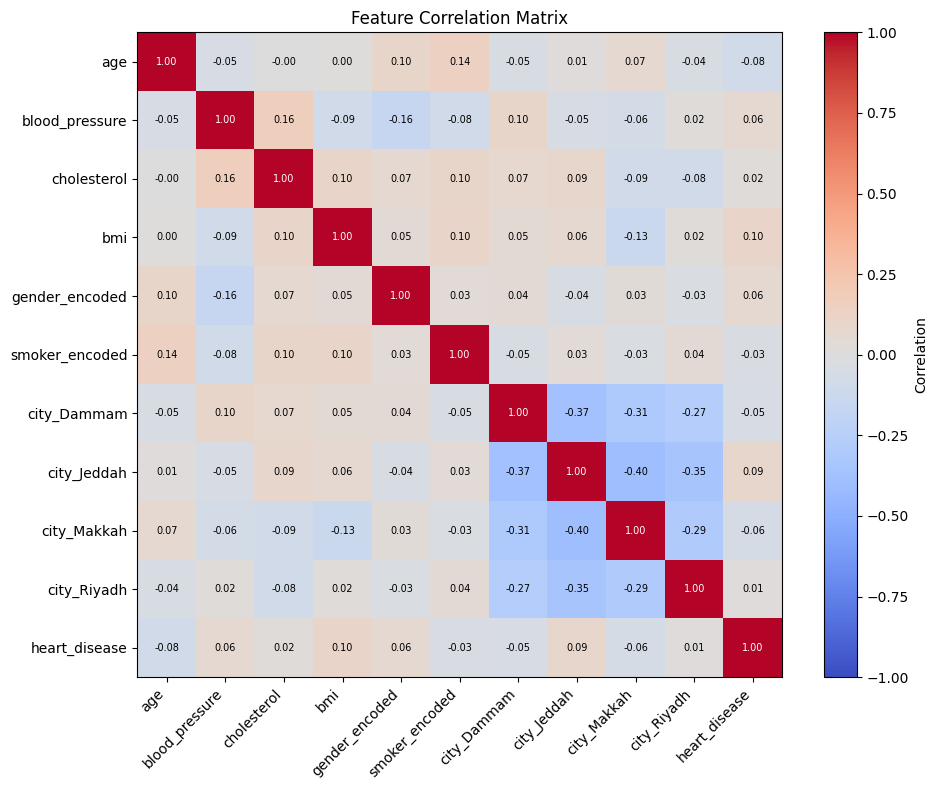

In [409]:
import matplotlib . pyplot as plt
import numpy as np

plt . figure ( figsize =(10 , 8) )
im = plt . imshow ( corr_matrix . values , cmap ='coolwarm' ,
vmin = -1 , vmax =1)
plt . colorbar ( im , label ='Correlation' )

# Add labels
ticks = range (len( corr_matrix . columns ) )
plt . xticks ( ticks , corr_matrix . columns , rotation =45 , ha ='right' )
plt . yticks ( ticks , corr_matrix . columns )

# Add correlation values on the heatmap
for i in range (len( corr_matrix ) ) :
    for j in range (len( corr_matrix ) ) :
        val = corr_matrix . values [i , j ]
        color = 'white' if abs( val ) > 0.5 else 'black'
        plt . text (j , i , f'{val :.2f}', ha ='center' , va ='center' ,
        fontsize =7 , color = color )

plt . title ('Feature Correlation Matrix' )
plt . tight_layout ()
plt . show ()

##7.3 Select Top Features


In [410]:
# Select features with absolute correlation > threshold
threshold = 0.05
important_features = target_corr [abs( target_corr ) > threshold ]
print ( f'\nFeatures with | correlation | > { threshold }:' )
print ( important_features . sort_values ( ascending = False ) . round (3) )

# Train with only the top features
top_features = important_features . index . tolist ()
X_selected = df_processed [ top_features ]. values

X_tr , X_te , y_tr , y_te = train_test_split (
X_selected , y , test_size =0.2 , random_state =42 , stratify = y )

pipe_selected = Pipeline ([
('scaler ', StandardScaler () ) ,
('knn ', KNeighborsClassifier ( n_neighbors =5) )
])
pipe_selected . fit ( X_tr , y_tr )
sel_acc = accuracy_score ( y_te , pipe_selected . predict ( X_te ) )

print ( f'\nAccuracy with ALL features : { pipe_acc :.2%} ')
print ( f'Accuracy with SELECTED features : { sel_acc :.2%} ')
print ( f'Features used : {len( top_features )} out of {len( feature_cols )} '
)


Features with | correlation | > 0.05:
bmi               0.103
city_Jeddah       0.093
blood_pressure    0.060
gender_encoded    0.058
city_Dammam      -0.054
city_Makkah      -0.058
age              -0.080
Name: heart_disease, dtype: float64

Accuracy with ALL features : 61.11% 
Accuracy with SELECTED features : 44.44% 
Features used : 7 out of 10 


#Task 7: Feature Selection


**1. Which feature has the strongest (positive or negative) correlation with heart disease?**

> The feature with the strongest positive correlation with heart disease is bmi (0.103). The feature with the strongest negative correlation is age (-0.080). Overall, bmi has the strongest absolute correlation.

In [411]:
#Try different threshold values (0.03, 0.08, 0.10). How does accuracy change?

#threshold value = 0.03:

threshold = 0.03
important_features = target_corr [abs( target_corr ) > threshold ]
print ( f'\nFeatures with | correlation | > { threshold }:' )
print ( important_features . sort_values ( ascending = False ) . round (3) )

# Train with only the top features
top_features = important_features . index . tolist ()
X_selected = df_processed [ top_features ]. values

X_tr , X_te , y_tr , y_te = train_test_split (
X_selected , y , test_size =0.2 , random_state =42 , stratify = y )

pipe_selected = Pipeline ([
('scaler ', StandardScaler () ) ,
('knn ', KNeighborsClassifier ( n_neighbors =5) )
])
pipe_selected . fit ( X_tr , y_tr )
sel_acc = accuracy_score ( y_te , pipe_selected . predict ( X_te ) )

print ( f'\nAccuracy with ALL features : { pipe_acc :.2%} ')
print ( f'Accuracy with SELECTED features : { sel_acc :.2%} ')
print ( f'Features used : {len( top_features )} out of {len( feature_cols )} '
)

print("\n-------------------------------------------------")

#threshold value = 0.08:

threshold = 0.08
important_features = target_corr [abs( target_corr ) > threshold ]
print ( f'\nFeatures with | correlation | > { threshold }:' )
print ( important_features . sort_values ( ascending = False ) . round (3) )

# Train with only the top features
top_features = important_features . index . tolist ()
X_selected = df_processed [ top_features ]. values

X_tr , X_te , y_tr , y_te = train_test_split (
X_selected , y , test_size =0.2 , random_state =42 , stratify = y )

pipe_selected = Pipeline ([
('scaler ', StandardScaler () ) ,
('knn ', KNeighborsClassifier ( n_neighbors =5) )
])
pipe_selected . fit ( X_tr , y_tr )
sel_acc = accuracy_score ( y_te , pipe_selected . predict ( X_te ) )

print ( f'\nAccuracy with ALL features : { pipe_acc :.2%} ')
print ( f'Accuracy with SELECTED features : { sel_acc :.2%} ')
print ( f'Features used : {len( top_features )} out of {len( feature_cols )} '
)

print("\n-------------------------------------------------")


#threshold value = 0.10:

threshold = 0.10
important_features = target_corr [abs( target_corr ) > threshold ]
print ( f'\nFeatures with | correlation | > { threshold }:' )
print ( important_features . sort_values ( ascending = False ) . round (3) )

# Train with only the top features
top_features = important_features . index . tolist ()
X_selected = df_processed [ top_features ]. values

X_tr , X_te , y_tr , y_te = train_test_split (
X_selected , y , test_size =0.2 , random_state =42 , stratify = y )

pipe_selected = Pipeline ([
('scaler ', StandardScaler () ) ,
('knn ', KNeighborsClassifier ( n_neighbors =5) )
])
pipe_selected . fit ( X_tr , y_tr )
sel_acc = accuracy_score ( y_te , pipe_selected . predict ( X_te ) )

print ( f'\nAccuracy with ALL features : { pipe_acc :.2%} ')
print ( f'Accuracy with SELECTED features : { sel_acc :.2%} ')
print ( f'Features used : {len( top_features )} out of {len( feature_cols )} '
)


Features with | correlation | > 0.03:
bmi               0.103
city_Jeddah       0.093
blood_pressure    0.060
gender_encoded    0.058
smoker_encoded   -0.034
city_Dammam      -0.054
city_Makkah      -0.058
age              -0.080
Name: heart_disease, dtype: float64

Accuracy with ALL features : 61.11% 
Accuracy with SELECTED features : 52.78% 
Features used : 8 out of 10 

-------------------------------------------------

Features with | correlation | > 0.08:
bmi            0.103
city_Jeddah    0.093
Name: heart_disease, dtype: float64

Accuracy with ALL features : 61.11% 
Accuracy with SELECTED features : 61.11% 
Features used : 2 out of 10 

-------------------------------------------------

Features with | correlation | > 0.1:
bmi    0.103
Name: heart_disease, dtype: float64

Accuracy with ALL features : 61.11% 
Accuracy with SELECTED features : 47.22% 
Features used : 1 out of 10 


**2. Try different threshold values (0.03, 0.08, 0.10). How does accuracy change?**

> When the correlation threshold was 0.03 (8 features), the accuracy was 52.78%. With a threshold of 0.08 (2 features), the accuracy remained 61.11%, matching the accuracy of using all features. However, increasing the threshold to 0.10 (1 feature) reduced the accuracy to 47.22%. This shows that selecting features based on correlation can improve or maintain accuracy, but too aggressive selection can hurt performance.

**3. Think: Why might using fewer features sometimes give better accuracy? (Hint: consider the “curse of dimensionality.”)**

> Using fewer features can sometimes improve accuracy because it helps to combat the 'curse of dimensionality.' With too many features, a model can become confused by irrelevant or redundant information, making it harder to find patterns and leading to overfitting. Reducing features can make the model simpler, faster, and more robust by focusing on the most important aspects of the data.

#Part 8: Putting It All Together – Full Workflow

In [412]:
import pandas as pd
import numpy as np
from sklearn . model_selection import train_test_split
from sklearn . impute import SimpleImputer
from sklearn . preprocessing import StandardScaler , LabelEncoder
from sklearn . pipeline import Pipeline
from sklearn . neighbors import KNeighborsClassifier
from sklearn . tree import DecisionTreeClassifier
from sklearn . metrics import accuracy_score , classification_report

# ===== STEP 1: Load Raw Data =====
# (Re - create the messy dataset )
np . random . seed (42)
n = 200
data = {
'age': np . random . randint (18 , 80 , n ) . astype ( float ) ,
'blood_pressure': np . round ( np . random . uniform (90 , 180 , n ) , 1) ,
'cholesterol': np . round ( np . random . uniform (150 , 350 , n ) , 1) ,
'bmi': np . round ( np . random . uniform (18 , 42 , n ) , 1) ,
'gender': np . random . choice ([ 'Male', 'Female'] , n ) ,
'city': np . random . choice (
['Jeddah', 'Riyadh', 'Dammam', 'Makkah'] , n ) ,
'smoker': np . random . choice ([ 'Yes', 'No'] , n , p =[0.3 , 0.7]) ,
'heart_disease': np . random . choice ([0 , 1] , n , p =[0.6 , 0.4])
}
df = pd . DataFrame ( data )
missing_idx = np . random . choice (n , 20 , replace = False )
df . loc [ missing_idx [:10] , 'age'] = np . nan
df . loc [ missing_idx [10:15] , 'blood_pressure'] = np . nan
df . loc [ missing_idx [15:] , 'cholesterol'] = np . nan

print ('=== Step 1: Raw Data === ')
print ( f'Shape : {df. shape } , Missing : {df. isnull ().sum ().sum ()}')

# ===== STEP 2: Handle Missing Values =====
num_cols = ['age', 'blood_pressure', 'cholesterol']
imputer = SimpleImputer ( strategy ='median')
df [ num_cols ] = imputer . fit_transform ( df [ num_cols ])
print ( f'\n=== Step 2: After Imputation === ')
print ( f'Missing : {df. isnull ().sum ().sum ()}')

# ===== STEP 3: Encode Categorical Variables =====
le = LabelEncoder ()
df ['gender'] = le . fit_transform ( df ['gender'])
df ['smoker'] = le . fit_transform ( df ['smoker'])
df = pd . concat ([ df , pd . get_dummies ( df ['city'] , prefix ='city') ] ,
axis =1)
df = df . drop ( columns =[ 'city'])
print ( f'\n=== Step 3: After Encoding === ')
print ( f'Columns : { list (df. columns )}')

# ===== STEP 4: Separate Features and Target =====
X = df . drop ( columns =[ 'heart_disease']) . values
y = df ['heart_disease']. values

# ===== STEP 5: Split Data =====
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )

# ===== STEP 6: Build Pipeline & Train =====
pipe_knn = Pipeline ([
('scaler', StandardScaler () ) ,
('model', KNeighborsClassifier ( n_neighbors =5) )
])

pipe_dt = Pipeline ([
('scaler', StandardScaler () ) ,
('model', DecisionTreeClassifier ( random_state =42) )
])

pipe_knn . fit ( X_train , y_train )
pipe_dt . fit ( X_train , y_train )

# ===== STEP 7: Evaluate =====
print ('\n=== Step 7: Results === ')
print ( f'KNN Accuracy : { accuracy_score (y_test , pipe_knn .
predict ( X_test )) :.2%} ')
print ( f'Decision Tree Accuracy : { accuracy_score (y_test , pipe_dt .
predict ( X_test )) :.2%} ')

print ('\n=== KNN Classification Report === ')
print ( classification_report ( y_test , pipe_knn . predict ( X_test ) ,
target_names =[ 'No Disease', 'Disease']) )

=== Step 1: Raw Data === 
Shape : (200, 8) , Missing : 20

=== Step 2: After Imputation === 
Missing : 0

=== Step 3: After Encoding === 
Columns : ['age', 'blood_pressure', 'cholesterol', 'bmi', 'gender', 'smoker', 'heart_disease', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']

=== Step 7: Results === 
KNN Accuracy : 50.00% 
Decision Tree Accuracy : 52.50% 

=== KNN Classification Report === 
              precision    recall  f1-score   support

  No Disease       0.54      0.68      0.60        22
     Disease       0.42      0.28      0.33        18

    accuracy                           0.50        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.50      0.48        40



#Part 9: Summary and Key Takeaways

**1. Here's a quick summary of what we've done in this notebook:**

> In this notebook, we've walked through essential data preprocessing and feature engineering steps for machine learning. We started by creating a messy dataset, then learned how to handle missing values by imputing them. Next, we encoded categorical data into numerical formats. We then explored feature scaling, comparing StandardScaler and MinMaxScaler, and saw how scaling significantly impacts models like K-Nearest Neighbors (KNN), while having less effect on Decision Trees. Finally, we built and utilized preprocessing pipelines to streamline our workflow and perform feature selection based on correlation.

**2. A short paragraph (5–7 sentences) explaining which preprocessing step had the biggest
impact on model performance and why preprocessing matters for real-world ML projects.**

> The preprocessing step with the biggest impact on model performance was feature scaling, especially for the K-Nearest Neighbors (KNN) model. Without scaling, KNN's accuracy was significantly lower because features with larger numerical ranges dominated the distance calculations. Preprocessing matters greatly for real-world machine learning projects because raw data is often messy, containing missing values, inconsistent formats, and varying scales. Applying steps like imputation, encoding, and scaling transforms this raw data into a clean and usable format, which is essential for models to learn effectively. This ultimately leads to more accurate, robust, and reliable machine learning predictions.